# 聚类算法对比 — K-Means vs DBSCAN vs 层次聚类

**核心目标**：在**人造数据**上直观对比三种经典聚类算法的本质差异，理解各自的适用场景。
- **K-Means**：质心聚类，适合球形簇
- **DBSCAN**：密度聚类，适合任意形状 + 有噪声的数据
- **层次聚类（Hierarchical）**：树状聚类，可输出完整合并过程


## 1. 环境配置


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("环境配置完成")


环境配置完成


## 2. 生成三种形状的人工数据

**为什么要先看人造数据**：真实数据你永远不知道"真实簇"长什么样。人造数据的答案是已知的，可以清楚看出算法是否做对。

- **月牙形 moons**：两个弯月交错，非凸簇
- **环形 circles**：内外两个环，非凸簇
- **球形 blobs**：三个标准高斯团，凸簇（K-Means 的舒适区）


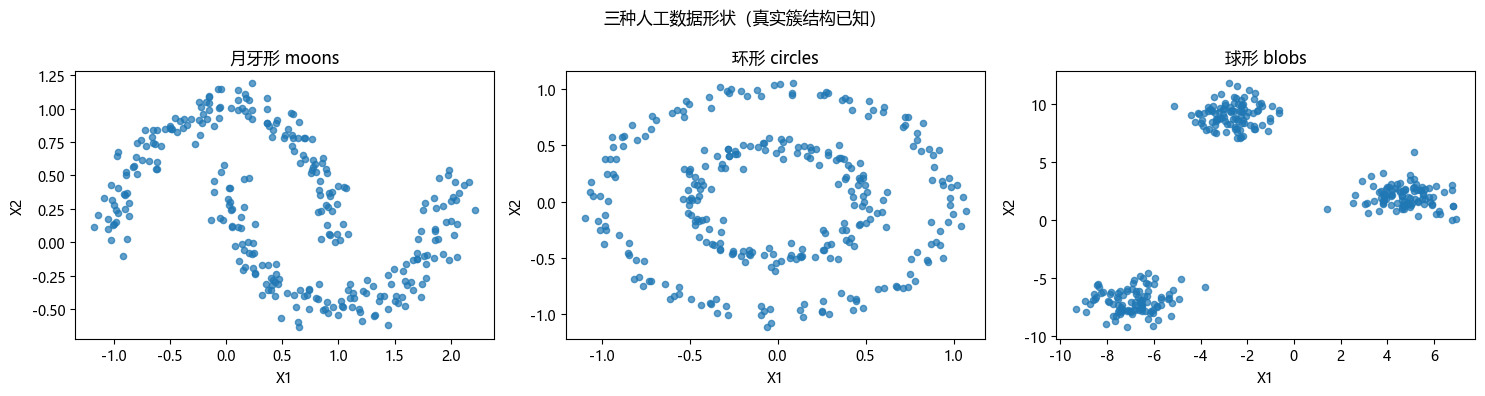

In [3]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=RANDOM_STATE)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, X, title in [
    (axes[0], X_moons, "月牙形 moons"),
    (axes[1], X_circles, "环形 circles"),
    (axes[2], X_blobs, "球形 blobs"),
]:
    ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.suptitle("三种人工数据形状（真实簇结构已知）")
plt.tight_layout()
plt.show()

# 真实标签（y_moons/y_circles/y_blobs）保留下来，第 6 节用 ARI 做量化评估


## 3. K-Means：非球形数据上的「失败」演示

K-Means 假设簇是凸的球形（由质心均匀划分 Voronoi 区域）。即使知道真实簇数 K=2，月牙和环形依然会被硬切成两半。


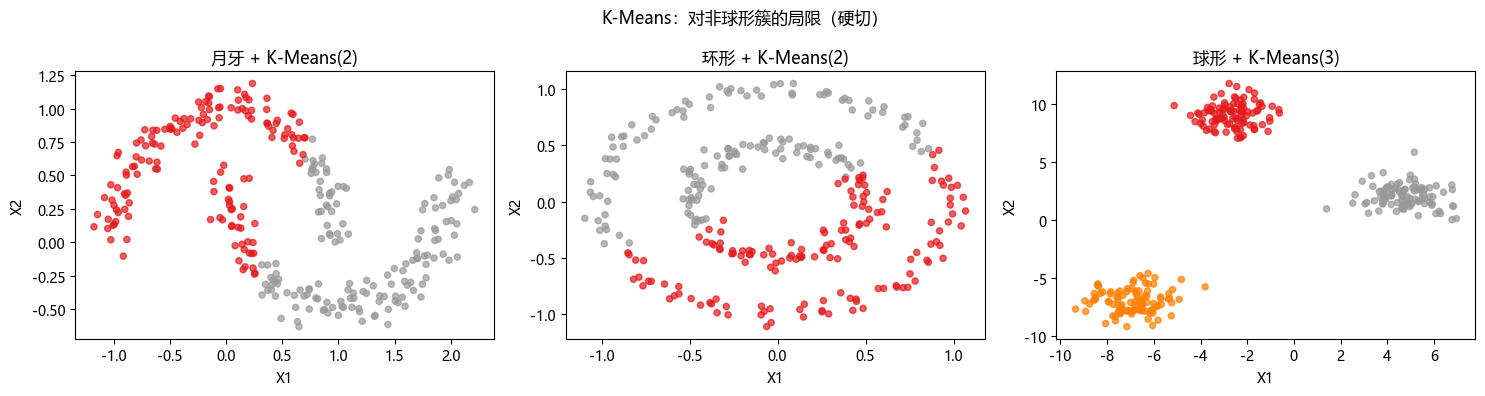

In [4]:
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_moons)
kmeans_circles = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_circles)
kmeans_blobs = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, X, labels, title in [
    (axes[0], X_moons, kmeans_moons.labels_, "月牙 + K-Means(2)"),
    (axes[1], X_circles, kmeans_circles.labels_, "环形 + K-Means(2)"),
    (axes[2], X_blobs, kmeans_blobs.labels_, "球形 + K-Means(3)"),
]:
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set1", s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.suptitle("K-Means：对非球形簇的局限（硬切）")
plt.tight_layout()
plt.show()


In [5]:
print("K-Means 核心局限：默认假设簇是凸的球形（由质心均匀划分 Voronoi 区域）")
print("→ 对月牙/环形这类非凸簇，即使 K 正确也无法正确聚类")


K-Means 核心局限：默认假设簇是凸的球形（由质心均匀划分 Voronoi 区域）
→ 对月牙/环形这类非凸簇，即使 K 正确也无法正确聚类


## 4. DBSCAN：非球形数据上的「胜利」演示

DBSCAN 按密度聚类，eps 控制邻域半径，min_samples 控制核心点密度阈值。它能自动识别任意形状簇，不需要预设 K。


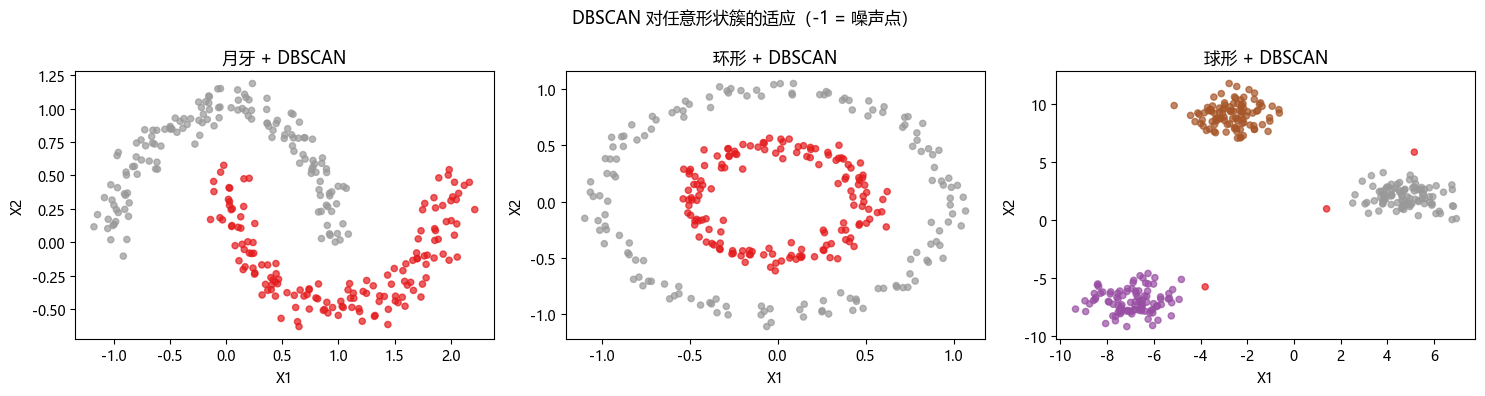

moons    找到簇数: 2, 噪声点: 0
circles  找到簇数: 2, 噪声点: 0
blobs    找到簇数: 3, 噪声点: 3


In [6]:
dbscan_moons = DBSCAN(eps=0.25, min_samples=5).fit(X_moons)
dbscan_circles = DBSCAN(eps=0.2, min_samples=5).fit(X_circles)
dbscan_blobs = DBSCAN(eps=1.2, min_samples=5).fit(X_blobs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, X, labels, title in [
    (axes[0], X_moons, dbscan_moons.labels_, "月牙 + DBSCAN"),
    (axes[1], X_circles, dbscan_circles.labels_, "环形 + DBSCAN"),
    (axes[2], X_blobs, dbscan_blobs.labels_, "球形 + DBSCAN"),
]:
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="Set1", s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.suptitle("DBSCAN 对任意形状簇的适应（-1 = 噪声点）")
plt.tight_layout()
plt.show()

for name, labels in [("moons", dbscan_moons.labels_), ("circles", dbscan_circles.labels_), ("blobs", dbscan_blobs.labels_)]:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"{name:8s} 找到簇数: {n_clusters}, 噪声点: {n_noise}")


In [7]:
print("DBSCAN 核心优势：按密度聚类 → 任意形状簇 + 自动定K + 识别噪声")
print("代价：对 eps / min_samples 敏感，需要调参；高维数据距离度量失效")


DBSCAN 核心优势：按密度聚类 → 任意形状簇 + 自动定K + 识别噪声
代价：对 eps / min_samples 敏感，需要调参；高维数据距离度量失效


## 5. 层次聚类：谱系图看全过程

层次聚类不用预设 K，通过逐步合并相似样本（ward 法最小化合并后簇内方差）输出树状结构，从树状图上可任意选层作为簇数。


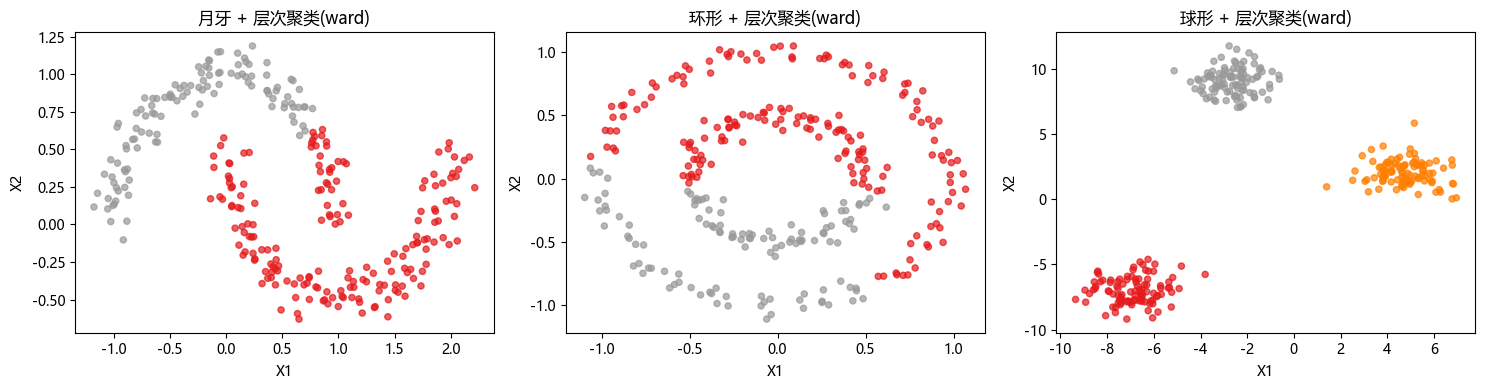

层次聚类优点：不用预设 K（可从树状图切任意层）、可输出完整合并过程
层次聚类缺点：计算复杂度 O(n²)，不适合大数据；ward 法同样偏向球形簇


In [8]:
hier_moons = AgglomerativeClustering(n_clusters=2, linkage="ward").fit(X_moons)
hier_circles = AgglomerativeClustering(n_clusters=2, linkage="ward").fit(X_circles)
hier_blobs = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X_blobs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=hier_moons.labels_, cmap="Set1", s=20, alpha=0.7)
axes[0].set_title("月牙 + 层次聚类(ward)")
axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=hier_circles.labels_, cmap="Set1", s=20, alpha=0.7)
axes[1].set_title("环形 + 层次聚类(ward)")
axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=hier_blobs.labels_, cmap="Set1", s=20, alpha=0.7)
axes[2].set_title("球形 + 层次聚类(ward)")
for ax in axes:
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.tight_layout()
plt.show()

print("层次聚类优点：不用预设 K（可从树状图切任意层）、可输出完整合并过程")
print("层次聚类缺点：计算复杂度 O(n²)，不适合大数据；ward 法同样偏向球形簇")


## 6. 量化验证：ARI 对比真实簇

人造数据带**真实标签**，正好可以用 **ARI（Adjusted Rand Index，调整兰德指数）** 客观衡量"聚类结果 vs 真实簇"的一致性（越接近 1 越准）。


In [9]:
ari_table = pd.DataFrame(
    {
        "月牙(moons)": [
            adjusted_rand_score(y_moons, kmeans_moons.labels_),
            adjusted_rand_score(y_moons, dbscan_moons.labels_),
            adjusted_rand_score(y_moons, hier_moons.labels_),
        ],
        "环形(circles)": [
            adjusted_rand_score(y_circles, kmeans_circles.labels_),
            adjusted_rand_score(y_circles, dbscan_circles.labels_),
            adjusted_rand_score(y_circles, hier_circles.labels_),
        ],
        "球形(blobs)": [
            adjusted_rand_score(y_blobs, kmeans_blobs.labels_),
            adjusted_rand_score(y_blobs, dbscan_blobs.labels_),
            adjusted_rand_score(y_blobs, hier_blobs.labels_),
        ],
    },
    index=["K-Means", "DBSCAN", "层次聚类(ward)"],
).round(4)
ari_table


,月牙(moons),环形(circles),球形(blobs)
K-Means,0.2610,-0.0033,1.000
DBSCAN,1.0000,1.0000,0.985
层次聚类(ward),0.5968,0.0013,1.000


### ARI 数字怎么读
- **行方向看（同一数据）**：K-Means 在月牙/环形上 ARI 明显偏低（硬切导致），DBSCAN 接近 1
- **列方向看（同一算法）**：DBSCAN 在三种形状上都稳定高分，说明它对"簇形状"不挑剔
- **球形列**：三种算法都接近 1 → 球形簇是大家都能搞定的"安全区"


## 6. Part 1 小结

| 数据形状 | 真实簇数 | K-Means | DBSCAN | 层次聚类(ward) |
|---------|---------|---------|--------|---------------|
| 月牙形 | 2 | ❌ 硬切两半 | ✅ 正确 | ⚠️ 基本正确 |
| 环形 | 2 | ❌ 扇形切开 | ✅ 正确 | ⚠️ 基本正确 |
| 球形 | 3 | ✅ 正确 | ✅ 正确 | ✅ 正确 |

**核心结论**：
- K-Means：快且好用，但只适合球形簇 + 预先知道大概簇数
- DBSCAN：适合任意形状 + 有噪声的数据，但需调 eps/min_samples
- 层次聚类：适合小数据 + 想看完整聚类过程/树状图
